In [1]:
!git clone https://github.com/KaustubhMukdam/Pneumonia-Detection /kaggle/working/Pneumonia-Detection

Cloning into '/kaggle/working/Pneumonia-Detection'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 54 (delta 7), reused 41 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 494.48 KiB | 2.81 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [2]:
import os
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
confusion_matrix,
classification_report,
roc_curve
)

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_FRACTION = 0.15
EPOCHS = 25
THRESHOLD = 0.50

os.environ['PYTHONHASSHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
DATASET_ROOT = Path(
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/"
    "chest_xray/chest_xray"
)

TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"

LABEL_TO_ID = {
    "NORMAL": 0,
    "PNEUMONIA": 1,
}

VALID_EXTENSIONS = {".jpeg", ".jpg"}

assert TRAIN_DIR.exists(), f"Missing directory: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Missing directory: {TEST_DIR}"

# Build File Manifests

In [4]:
def build_manifest(split_dir: Path) -> pd.DataFrame:
    records = []

    for class_name, label in LABEL_TO_ID.items():
        class_dir = split_dir / class_name

        for image_path in sorted(class_dir.iterdir()):
            if image_path.suffix.lower() in VALID_EXTENSIONS:
                records.append(
                    {
                        "path" : str(image_path),
                        "label" : label,
                        "class_name" : class_name,
                    }
                )

    return pd.DataFrame(records)

train_full_df = build_manifest(TRAIN_DIR)
test_df = build_manifest(TEST_DIR)

print("Raw training images:", len(train_full_df))
print("Test images:", len(test_df))
print("\nRaw training class counts:")
print(train_full_df["class_name"].value_counts())

Raw training images: 5216
Test images: 624

Raw training class counts:
class_name
PNEUMONIA    3875
NORMAL       1341
Name: count, dtype: int64


# Duplicate-safe validation split
Prevents byte-identical training images from being split between our new training and validation sets

In [5]:
def file_sha256(file_path: str) -> str:
    digest = hashlib.sha256()

    with open(file_path, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)

    return digest.hexdigest()

train_full_df["sha256"] = train_full_df["path"].apply(file_sha256)
assert train_full_df.groupby("sha256")["label"].nunique().max() == 1

hash_groups_df = (
    train_full_df.groupby("sha256", as_index=False)
    .agg(
        label=("label", "first"),
        file_count=("path", "size"),
    )
)

train_hashes, val_hashes = train_test_split(
    hash_groups_df["sha256"],
    test_size=VALIDATION_FRACTION,
    random_state=SEED,
    stratify=hash_groups_df["label"],
)

train_df = (
    train_full_df[train_full_df["sha256"].isin(train_hashes)]
    .drop(columns="sha256")
    .reset_index(drop=True)
)

val_df = (
    train_full_df[train_full_df["sha256"].isin(val_hashes)]
    .drop(columns="sha256")
    .reset_index(drop=True)
)

assert set(train_df["path"]).isdisjoint(set(val_df["path"]))

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nTraining class counts:")
print(train_df["class_name"].value_counts())

print("\nValidation class counts:")
print(val_df["class_name"].value_counts())

Training images: 4432
Validation images: 784
Test images: 624

Training class counts:
class_name
PNEUMONIA    3292
NORMAL       1140
Name: count, dtype: int64

Validation class counts:
class_name
PNEUMONIA    583
NORMAL       201
Name: count, dtype: int64


# Tensorflow data pipeline

In [6]:
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    image = tf.cast(image, tf.float32) / 255.0

    return image, tf.cast(label, tf.float32)


def make_dataset(dataframe: pd.DataFrame, training: bool = False):
    paths = dataframe["path"].to_numpy(dtype=str)
    labels = dataframe["label"].to_numpy(dtype=np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return dataset


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

I0000 00:00:1786112577.843717      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786112577.846423      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Visual Sanity check

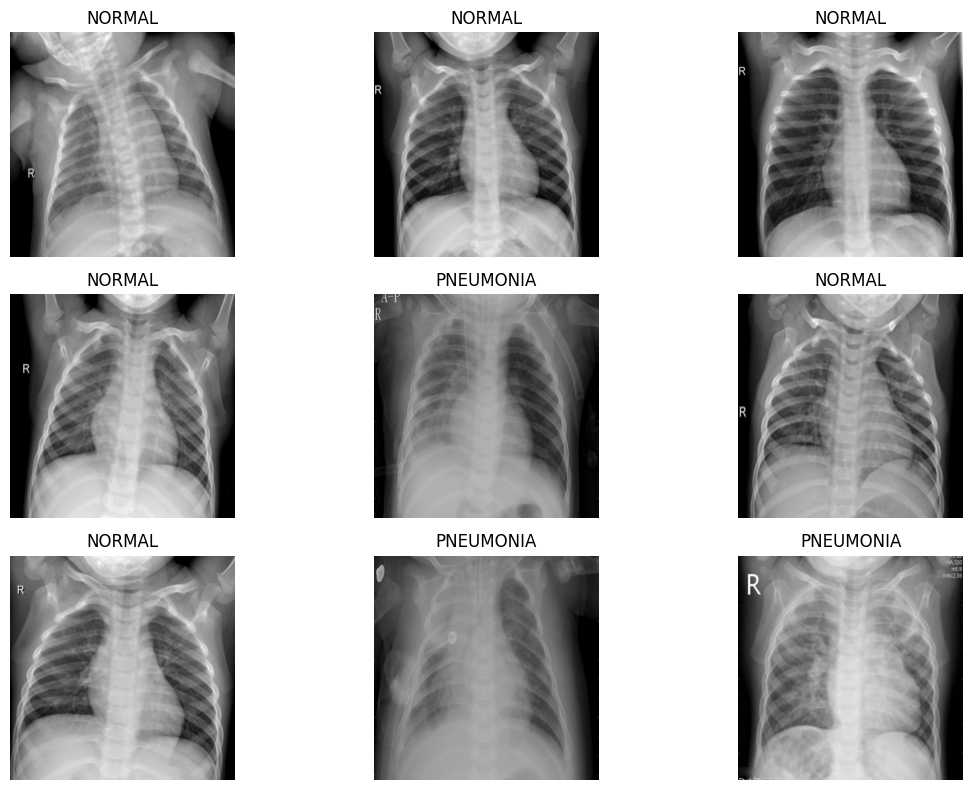

In [7]:
images, labels = next(iter(train_ds))
plt.figure(figsize=(12, 8))

for index in range(9):
    plt.subplot(3, 3, index + 1)
    plt.imshow(images[index])
    class_name = "PNEUMONIA" if labels[index].numpy() == 1 else "NORMAL"
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Conservative augmentation
Add small geometric changes during training

In [8]:
augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(
            factor = 7 / 360,
            fill_mode = "reflect",
        ),
        tf.keras.layers.RandomTranslation(
            height_factor=0.03,
            width_factor=0.03,
            fill_mode="reflect",
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.05,
            width_factor=0.05,
            fill_mode="reflect",
        )
    ],
    name="augmentation",
)

# Simple Convolutional Neural Networks Model

In [9]:
def conv_block(x, filters, dropout_rate):
    x = tf.keras.layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",#Same: Pad so that the output size is the same as the input size
        use_bias=False,
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        use_bias=False,
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)

    return x

inputs = tf.keras.Input(shape=(224, 224, 3), name="chest_xray")

x = augmentation(inputs)
x = conv_block(x, filters=32, dropout_rate=0.10)
x = conv_block(x, filters=64, dropout_rate=0.15)
x = conv_block(x, filters=128, dropout_rate=0.20)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    name="pneumonia_probability",
)(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name="baseline_cnn")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="roc_auc", curve="ROC"),
    ],
)

model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ chest_xray (InputLayer)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 296,673 (1.13 MB)

 Trainable params: 295,777 (1.13 MB)

 Non-trainable params: 896 (3.50 KB)

# Baseline Training

In [10]:
CHECKPOINT_PATH = "/kaggle/working/baseline_cnn_best.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/25


E0000 00:00:1786112586.358539      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/baseline_cnn_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.7811 - loss: 0.4313 - precision: 0.8485 - recall: 0.8486 - roc_auc: 0.8415
Epoch 1: val_loss improved from None to 1.56078, saving model to /kaggle/working/baseline_cnn_best.keras

Epoch 1: finished saving model to /kaggle/working/baseline_cnn_best.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 58s 346ms/step - accuracy: 0.8481 - loss: 0.3232 - precision: 0.8945 - recall: 0.9019 - roc_auc: 0.9134 - val_accuracy: 0.7436 - val_loss: 1.5608 - val_precision: 0.7436 - val_recall: 1.0000 - val_roc_auc: 0.5000
Epoch 2/25
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.8866 - loss: 0.2574 - precision: 0.9234 - recall: 0.9257 - roc_auc: 0.9446
Epoch 2: val_loss did not improve from 1.56078
139/139 ━━━━━━━━━━━━━━━━━━━━ 48s 344ms/step - accuracy: 0.8953 - loss: 0.2459 - precision: 0.9332 - recall: 0.9253 - roc_auc: 0.9496 - val_accuracy: 0.7436 - val_loss: 1.6790 - val_precision: 0.7436 - val_recall: 1.0000 - val_roc_auc: 0.5091
Epoch 3/25
139

# Training Curve Plot

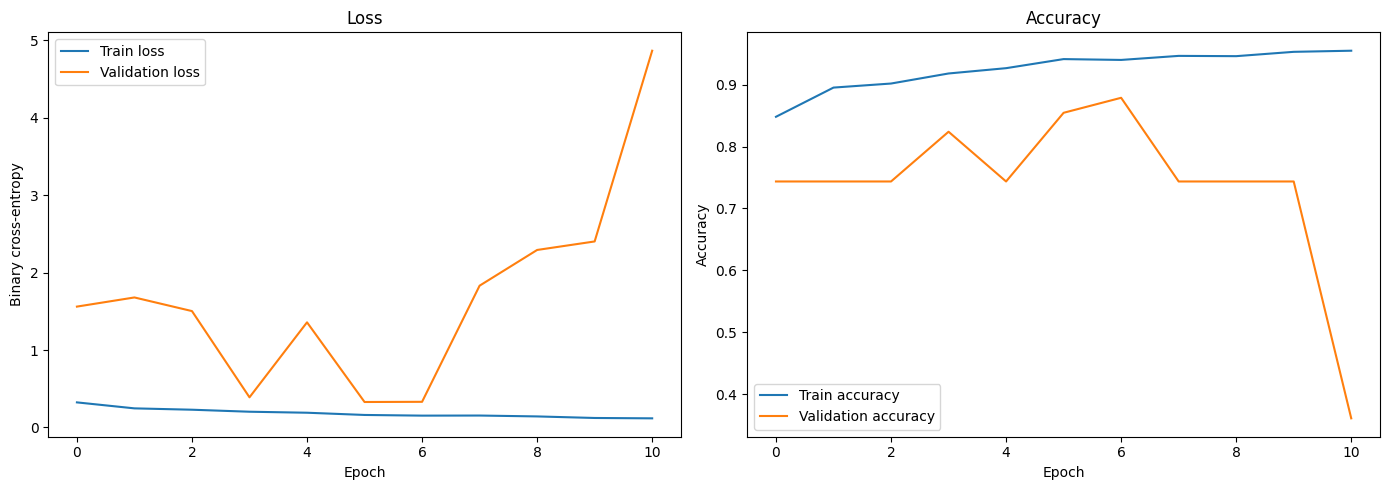

In [11]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["loss"], label="Train loss")
axes[0].plot(history_df["val_loss"], label="Validation loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend()

axes[1].plot(history_df["accuracy"], label="Train accuracy")
axes[1].plot(history_df["val_accuracy"], label="Validation accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

# final Test Evalutaion

In [12]:
best_model = tf.keras.models.load_model(CHECKPOINT_PATH)

test_probabilities = best_model.predict(test_ds, verbose=1).ravel()
test_predictions = (test_probabilities >= THRESHOLD).astype(int)
test_labels = test_df["label"].to_numpy()

tn, fp, fn, tp = confusion_matrix(
    test_labels,
    test_predictions,
    labels=[0, 1],
).ravel()

results = {
    "accuracy": accuracy_score(test_labels, test_predictions),
    "precision": precision_score(test_labels, test_predictions, zero_division=0),
    "recall_sensitivity": recall_score(test_labels, test_predictions, zero_division=0),
    "specificity": tn / (tn + fp),
    "f1_score": f1_score(test_labels, test_predictions, zero_division=0),
    "roc_auc": roc_auc_score(test_labels, test_probabilities),
    "true_negatives": tn,
    "false_positives": fp,
    "false_negatives": fn,
    "true_positives": tp,
}

pd.Series(results).round(4)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step


accuracy                0.6795
precision               0.6627
recall_sensitivity      0.9923
specificity             0.1581
f1_score                0.7947
roc_auc                 0.8257
true_negatives         37.0000
false_positives       197.0000
false_negatives         3.0000
true_positives        387.0000
dtype: float64

# Confusion Matrix, Classification report and ROC curve

              precision    recall  f1-score   support

      NORMAL     0.9250    0.1581    0.2701       234
   PNEUMONIA     0.6627    0.9923    0.7947       390

    accuracy                         0.6795       624
   macro avg     0.7938    0.5752    0.5324       624
weighted avg     0.7610    0.6795    0.5979       624



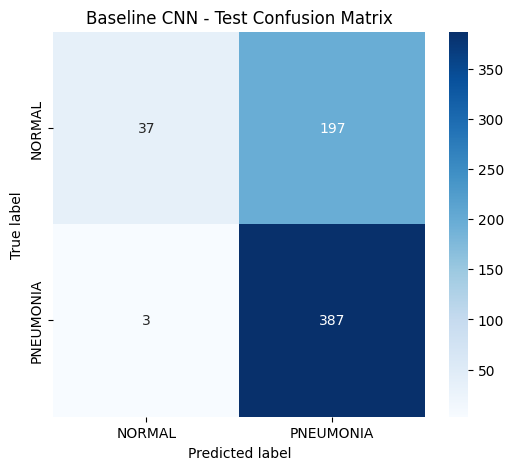

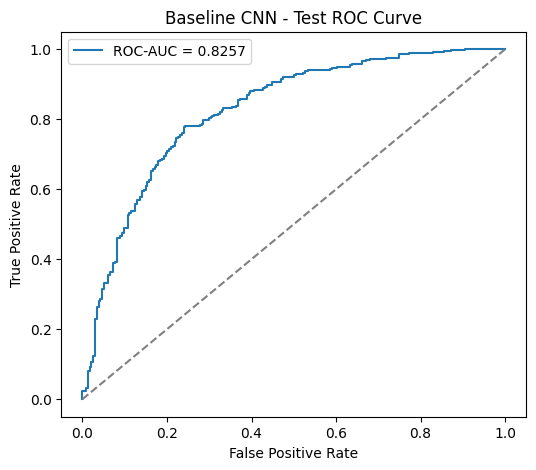

In [13]:
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=["NORMAL", "PNEUMONIA"],
        digits=4,
        zero_division=0,
    )
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(test_labels, test_predictions),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
)

plt.title("Baseline CNN - Test Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

false_positive_rate, true_positive_rate, _ = roc_curve(
    test_labels,
    test_probabilities,
)

plt.figure(figsize=(6, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"ROC-AUC = {results['roc_auc']:.4f}",
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline CNN - Test ROC Curve")
plt.legend()
plt.show()

# Threshold Tradeoff on Validation set

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

validation_probabilities = best_model.predict(val_ds, verbose=1).ravel()
validation_labels = val_df['label'].to_numpy()

threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.05):
    predictions = (validation_probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        validation_labels,
        predictions,
        labels=[0,1],
    ).ravel()

    threshold_rows.append(
        {
            "threshold" : round(float(threshold), 2),
            "sensitivity" : recall_score(
                validation_labels,
                predictions,
                zero_division=0,
            ),
            "specificity" : tn / (tn + fp),
            "predision" : precision_score(
                validation_labels,
                predictions,
                zero_division=0,
            ),
            "f1" : f1_score(
                validation_labels,
                predictions,
                zero_division=0,
            ),
            "false_negatives" : fn,
            "false_positivies" : fp,
        }
    )

threshold_results = pd.DataFrame(threshold_rows)
threshold_results

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step


,threshold,sensitivity,specificity,predision,f1,false_negatives,false_positivies
0,0.10,1.000000,0.004975,0.744572,0.853587,0,200
1,0.15,1.000000,0.029851,0.749357,0.856723,0,195
2,0.20,1.000000,0.104478,0.764089,0.866270,0,180
3,0.25,1.000000,0.154229,0.774236,0.872754,0,170
4,0.30,0.998285,0.199005,0.783311,0.877828,1,161
5,0.35,0.993139,0.253731,0.794239,0.882622,4,150
6,0.40,0.991424,0.303483,0.805014,0.888547,5,140
7,0.45,0.986278,0.373134,0.820257,0.895639,8,126
8,0.50,0.984563,0.477612,0.845361,0.909667,9,105
9,0.55,0.977702,0.542289,0.861027,0.915663,13,92


In [17]:
FINAL_THRESHOLD = 0.65

final_predictions = (
    test_probabilities >= FINAL_THRESHOLD
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    test_labels,
    final_predictions,
    labels=[0, 1],
).ravel()

final_results = {
    "threshold": FINAL_THRESHOLD,
    "accuracy": accuracy_score(test_labels, final_predictions),
    "precision": precision_score(
        test_labels,
        final_predictions,
        zero_division=0,
    ),
    "sensitivity": recall_score(
        test_labels,
        final_predictions,
        zero_division=0,
    ),
    "specificity": tn / (tn + fp),
    "f1_score": f1_score(
        test_labels,
        final_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(test_labels, test_probabilities),
    "true_negatives": tn,
    "false_positives": fp,
    "false_negatives": fn,
    "true_positives": tp,
}

pd.Series(final_results).round(4)

threshold            0.6500
accuracy             0.7308
precision            0.7110
sensitivity          0.9590
specificity          0.3504
f1_score             0.8166
roc_auc              0.8257
true_negatives      82.0000
false_positives    152.0000
false_negatives     16.0000
true_positives     374.0000
dtype: float64